# Notebook 05 - Transfer Learning ViT

VisionNarrator | Stage 5

---

## 1. Objective

Replace the scratch encoder with a pretrained ViT and compare.

best_scratch_vit.pt (baseline)
      ↓
Pretrained ViT-B/16 → projection → decoder
      ↓
Freeze ViT → train decoder
      ↓
Unfreeze ViT → fine-tune
      ↓
Compare all 3 models

Setup: imports, configuration, device, paths.

PRETRAINED_MODEL_NAME = google/vit-base-patch16-224-in21k
EMBED_DIM = 256
DECODER_DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1
MAX_CAPTION_LEN = 25
BATCH_SIZE = 32
EPOCHS_FROZEN = 3
EPOCHS_FINETUNE = 2
LR_DECODER = 3e-4
LR_FINETUNE_VIT = 1e-5
LR_FINETUNE_DECODER = 5e-5
EVAL_NUM_IMAGES = 500
NUM_WORKERS = 4

LIMIT_TRAIN_BATCHES / LIMIT_VAL_BATCHES cap the batches per epoch. Leave them as None on GPU; set small values (e.g. 200 / 30) for a CPU run.


In [9]:
import math
import platform
import shutil
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from transformers import ViTModel, AutoImageProcessor

PRETRAINED_MODEL_NAME = "google/vit-base-patch16-224-in21k"

EMBED_DIM = 256
DECODER_DEPTH = 4
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1
MAX_CAPTION_LEN = 25

BATCH_SIZE = 32
EPOCHS_FROZEN = 3
EPOCHS_FINETUNE = 2
LR_DECODER = 3e-4
LR_FINETUNE_VIT = 1e-5
LR_FINETUNE_DECODER = 5e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
WARMUP_FRAC = 0.05

EVAL_NUM_IMAGES = 500
RANDOM_SEED = 42
NUM_WORKERS = 4
LOG_EVERY = 100
LIMIT_TRAIN_BATCHES = None
LIMIT_VAL_BATCHES = None

EFFECTIVE_NUM_WORKERS = NUM_WORKERS
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
USE_AMP = device.type == "cuda"

def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

BASE_DIR = resolve_base_dir()
DATA_DIR = BASE_DIR / "src" / "data"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
MODEL_DIR = BASE_DIR / "src" / "models"
CHECKPOINT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"USE_AMP={USE_AMP}")
print(f"PRETRAINED_MODEL_NAME={PRETRAINED_MODEL_NAME}")
print(f"EPOCHS_FROZEN={EPOCHS_FROZEN} | EPOCHS_FINETUNE={EPOCHS_FINETUNE}")
print(f"LR_DECODER={LR_DECODER} | LR_FINETUNE_VIT={LR_FINETUNE_VIT} | LR_FINETUNE_DECODER={LR_FINETUNE_DECODER}")
print(f"LIMIT_TRAIN_BATCHES={LIMIT_TRAIN_BATCHES} | LIMIT_VAL_BATCHES={LIMIT_VAL_BATCHES}")
print(f"EFFECTIVE_NUM_WORKERS={EFFECTIVE_NUM_WORKERS}")
print(f"BASE_DIR: {BASE_DIR}")


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
USE_AMP=True
PRETRAINED_MODEL_NAME=google/vit-base-patch16-224-in21k
EPOCHS_FROZEN=3 | EPOCHS_FINETUNE=2
LR_DECODER=0.0003 | LR_FINETUNE_VIT=1e-05 | LR_FINETUNE_DECODER=5e-05
LIMIT_TRAIN_BATCHES=None | LIMIT_VAL_BATCHES=None
BASE_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator


## 2. Why Transfer Learning?

ScratchViT (Notebooks 03/04)
- 22k training images, random initialization
- ~5M parameters, 6 layers, 128×128 input
- Must learn edges, textures, objects and language at the same time

Pretrained ViT-B/16
- 14M images (ImageNet-21k), 12 layers, 86M parameters
- Already encodes general visual features

Transfer learning reuses those features:

Pretrained ViT
      ↓
Projection 768 → 256
      ↓
Transformer decoder

Phase 1: freeze the ViT, train only projection + decoder.
Phase 2: unfreeze the ViT, fine-tune everything with a small learning rate.

Same vocabulary, same decoder architecture and same test images for all three models, so the comparison isolates the encoder.


## 3. Scratch ViT Baseline

src/models/vit_captioner.pt (Notebook 04)
      ↓
checkpoints/best_scratch_vit.pt (kept aside, never overwritten here)
      ↓
Rebuild ScratchViT + decoder → load weights

The vocabulary and decoder configuration are read from this checkpoint and reused for the transfer model.


In [10]:
class Vocabulary:
    def __init__(self, min_freq=5):
        self.min_freq = min_freq
        self.itos = ["<pad>", "<sos>", "<eos>", "<unk>"]
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

    @staticmethod
    def tokenize(text):
        return text.lower().strip().split()

    @classmethod
    def from_itos(cls, itos, min_freq=5):
        vocab = cls(min_freq=min_freq)
        vocab.itos = list(itos)
        vocab.stoi = {token: idx for idx, token in enumerate(vocab.itos)}
        return vocab

    def build(self, captions):
        counter = Counter()
        for caption in captions:
            counter.update(self.tokenize(caption))
        for word, freq in sorted(counter.items()):
            if freq >= self.min_freq:
                self.stoi[word] = len(self.itos)
                self.itos.append(word)

    def encode(self, text, max_len):
        tokens = self.tokenize(text)[: max_len - 2]
        ids = [self.stoi["<sos>"]] + [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens] + [self.stoi["<eos>"]]
        ids = ids + [self.stoi["<pad>"]] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            token = self.itos[idx]
            if token == "<eos>":
                break
            if token in ("<pad>", "<sos>"):
                continue
            words.append(token)
        return " ".join(words)

    def __len__(self):
        return len(self.itos)

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_chans=3, embed_dim=256):
        super().__init__()

        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.num_patches_h = img_size // patch_size
        self.num_patches_w = img_size // patch_size
        self.num_patches = self.num_patches_h * self.num_patches_w

        self.patch_dim = in_chans * patch_size * patch_size

        self.proj = nn.Linear(self.patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape

        assert H == self.img_size and W == self.img_size, \
            f"Expected image size {(self.img_size, self.img_size)}, got {(H, W)}"

        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, self.patch_dim)

        x = self.proj(patches)

        return x

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

class MLP(nn.Module):
    def __init__(self, embed_dim=256, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ScratchViT(nn.Module):
    def __init__(
        self,
        img_size=128,
        patch_size=16,
        in_chans=3,
        embed_dim=256,
        depth=6,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward_features(self, x):
        x = self.patch_embed(x)

        B = x.shape[0]

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        return x

    def forward_embedding(self, x):
        x = self.forward_features(x)
        cls_out = x[:, 0]
        return cls_out

    def forward(self, x):
        return self.forward_embedding(x)


In [11]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim=256, max_len=25):
        super().__init__()

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim))
        pe = torch.zeros(1, max_len, embed_dim)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

class MaskedSelfAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        causal_mask = torch.triu(torch.ones(N, N, device=x.device, dtype=torch.bool), diagonal=1)
        attn = attn.masked_fill(causal_mask, float("-inf"))
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

class CrossAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.q = nn.Linear(embed_dim, embed_dim)
        self.kv = nn.Linear(embed_dim, embed_dim * 2)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x, memory):
        B, N, D = x.shape
        M = memory.shape[1]

        q = self.q(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        kv = self.kv(memory).reshape(B, M, 2, self.num_heads, self.head_dim)
        kv = kv.permute(2, 0, 3, 1, 4)

        k, v = kv[0], kv[1]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

class DecoderMLP(nn.Module):
    def __init__(self, embed_dim=256, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x

class TransformerDecoderBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.self_attn = MaskedSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.cross_attn = CrossAttention(embed_dim, num_heads, dropout)

        self.norm3 = nn.LayerNorm(embed_dim)
        self.mlp = DecoderMLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x, memory):
        x = x + self.self_attn(self.norm1(x))
        x = x + self.cross_attn(self.norm2(x), memory)
        x = x + self.mlp(self.norm3(x))
        return x

class TransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=256,
        depth=4,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
        max_len=25,
        pad_idx=0,
    ):
        super().__init__()

        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_enc = PositionalEncoding(embed_dim, max_len)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerDecoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, tokens, memory):
        x = self.token_embed(tokens)
        x = self.pos_enc(x)
        x = self.drop(x)

        for block in self.blocks:
            x = block(x, memory)

        x = self.norm(x)
        logits = self.head(x)

        return logits

class ImageCaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, tokens):
        memory = self.encoder.forward_features(images)
        logits = self.decoder(tokens, memory)
        return logits


In [12]:
SCRATCH_SOURCE_PATH = MODEL_DIR / "vit_captioner.pt"
SCRATCH_CKPT_PATH = CHECKPOINT_DIR / "best_scratch_vit.pt"

if not SCRATCH_CKPT_PATH.exists():
    shutil.copy(SCRATCH_SOURCE_PATH, SCRATCH_CKPT_PATH)

scratch_ckpt = torch.load(SCRATCH_CKPT_PATH, map_location="cpu")
scratch_config = scratch_ckpt["config"]

assert scratch_config["embed_dim"] == EMBED_DIM
assert scratch_config["decoder_depth"] == DECODER_DEPTH
assert scratch_config["num_heads"] == NUM_HEADS
assert scratch_config["max_caption_len"] == MAX_CAPTION_LEN

vocab = Vocabulary.from_itos(scratch_ckpt["vocab_itos"], min_freq=scratch_config["min_word_freq"])

PAD_IDX = vocab.stoi["<pad>"]
SOS_IDX = vocab.stoi["<sos>"]
EOS_IDX = vocab.stoi["<eos>"]
UNK_IDX = vocab.stoi["<unk>"]

SCRATCH_IMG_SIZE = scratch_config["img_size"]

def captions_to_tensor(caption_list, max_len=MAX_CAPTION_LEN):
    return torch.tensor([vocab.encode(caption, max_len) for caption in caption_list], dtype=torch.long)

def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters())

def count_trainable(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

scratch_encoder = ScratchViT(
    img_size=scratch_config["img_size"],
    patch_size=scratch_config["patch_size"],
    in_chans=3,
    embed_dim=scratch_config["embed_dim"],
    depth=scratch_config["encoder_depth"],
    num_heads=scratch_config["num_heads"],
    mlp_ratio=scratch_config["mlp_ratio"],
    dropout=scratch_config["dropout"],
)

scratch_decoder = TransformerDecoder(
    vocab_size=len(vocab),
    embed_dim=scratch_config["embed_dim"],
    depth=scratch_config["decoder_depth"],
    num_heads=scratch_config["num_heads"],
    mlp_ratio=scratch_config["mlp_ratio"],
    dropout=scratch_config["dropout"],
    max_len=scratch_config["max_caption_len"],
    pad_idx=PAD_IDX,
)

scratch_model = ImageCaptioningModel(scratch_encoder, scratch_decoder)
scratch_model.load_state_dict(scratch_ckpt["model_state"])
scratch_model = scratch_model.to(device).eval()

print(f"Scratch checkpoint: {SCRATCH_CKPT_PATH}")
print(f"Vocabulary size: {len(vocab):,}")
print(f"Scratch config: {scratch_config}")
print(f"Scratch model parameters: {count_parameters(scratch_model):,}")
print(f"Scratch encoder parameters: {count_parameters(scratch_model.encoder):,}")
print(f"Scratch best val loss (Notebook 04): {scratch_ckpt['best_val_loss']:.4f}")


Scratch checkpoint: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\checkpoints\best_scratch_vit.pt
Vocabulary size: 6,619
Scratch config: {'img_size': 128, 'patch_size': 16, 'embed_dim': 256, 'encoder_depth': 6, 'decoder_depth': 4, 'num_heads': 8, 'mlp_ratio': 4.0, 'dropout': 0.1, 'max_caption_len': 25, 'min_word_freq': 5}
Scratch model parameters: 12,562,651
Scratch encoder parameters: 4,952,832
Scratch best val loss (Notebook 04): 3.0184


## 4. Load Flickr30k

train.csv
val.csv
test.csv

Same image-level splits as Notebooks 02 and 04.


In [13]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train images: {train_df['image'].nunique():,} | rows: {len(train_df):,}")
print(f"Val images:   {val_df['image'].nunique():,} | rows: {len(val_df):,}")
print(f"Test images:  {test_df['image'].nunique():,} | rows: {len(test_df):,}")


Train images: 22,248 | rows: 111,213
Val images:   4,767 | rows: 23,830
Test images:  4,768 | rows: 23,837


## 5. Transfer-Learning Preprocessing

The pretrained ViT dictates its own input format, read from its image processor config:

Resize → 224×224
Normalize → mean / std published with the model

Scratch model: 128×128, mean 0.5, std 0.5 (Notebook 02).
Transfer model: 224×224, pretrained mean/std.

Two loader sets share the same rows and only differ in resolution.

`Flickr30kDataset` / `ImageDataset` live in src/vision_data.py: DataLoader workers on Windows are spawned as fresh processes and can only import classes from a module, not from notebook cells. NUM_WORKERS worker processes decode and augment images in parallel so the GPU is not waiting on the CPU.

Every worker process loads the CUDA build of PyTorch, which counts against the Windows commit limit (RAM + pagefile). Only the train loader keeps `persistent_workers`; validation and evaluation loaders spawn workers for one pass and release them. If `WinError 1455 (paging file is too small)` appears, lower NUM_WORKERS or enlarge the pagefile.


In [14]:
image_processor = AutoImageProcessor.from_pretrained(PRETRAINED_MODEL_NAME)

PRETRAINED_IMG_SIZE = int(image_processor.size["height"])
PRETRAINED_MEAN = list(image_processor.image_mean)
PRETRAINED_STD = list(image_processor.image_std)

transfer_train_transform = T.Compose(
    [
        T.Resize((PRETRAINED_IMG_SIZE, PRETRAINED_IMG_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=PRETRAINED_MEAN, std=PRETRAINED_STD),
    ]
)

transfer_eval_transform = T.Compose(
    [
        T.Resize((PRETRAINED_IMG_SIZE, PRETRAINED_IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=PRETRAINED_MEAN, std=PRETRAINED_STD),
    ]
)

scratch_eval_transform = T.Compose(
    [
        T.Resize((SCRATCH_IMG_SIZE, SCRATCH_IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

sys.path.insert(0, str(BASE_DIR))
from src.vision_data import Flickr30kDataset, ImageDataset

def make_loader(dataset, shuffle, persistent):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=EFFECTIVE_NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=persistent and EFFECTIVE_NUM_WORKERS > 0,
        prefetch_factor=4 if EFFECTIVE_NUM_WORKERS > 0 else None,
    )

transfer_train_loader = make_loader(Flickr30kDataset(train_df, transform=transfer_train_transform), shuffle=True, persistent=True)
transfer_val_loader = make_loader(Flickr30kDataset(val_df, transform=transfer_eval_transform), shuffle=False, persistent=False)
scratch_val_loader = make_loader(Flickr30kDataset(val_df, transform=scratch_eval_transform), shuffle=False, persistent=False)

images, captions = next(iter(transfer_train_loader))

print(f"PRETRAINED_IMG_SIZE={PRETRAINED_IMG_SIZE}")
print(f"PRETRAINED_MEAN={PRETRAINED_MEAN}")
print(f"PRETRAINED_STD={PRETRAINED_STD}")
print(f"Transfer train batches: {len(transfer_train_loader):,}")
print(f"Transfer val batches:   {len(transfer_val_loader):,}")
print(f"images.shape: {tuple(images.shape)}")
print(f"pixel range: ({images.min().item():.3f}, {images.max().item():.3f})")
print(f"Sample caption: {captions[0]}")


PRETRAINED_IMG_SIZE=224
PRETRAINED_MEAN=[0.5, 0.5, 0.5]
PRETRAINED_STD=[0.5, 0.5, 0.5]
Transfer train batches: 3,476
Transfer val batches:   745
images.shape: (32, 3, 224, 224)
pixel range: (-1.000, 1.000)
Sample caption: A young girl with a scarf on her head , not yet in her mid teens , gazing at something that may have caught her interest .


## 6. Load Pretrained ViT

google/vit-base-patch16-224-in21k

ViT-B/16 pretrained on ImageNet-21k, loaded through Hugging Face `transformers`. The pooling/classification head is dropped (`add_pooling_layer=False`); only the encoder is kept.

First run downloads ~350 MB and caches it locally.


In [15]:
vit = ViTModel.from_pretrained(PRETRAINED_MODEL_NAME, add_pooling_layer=False)
vit = vit.to(device).eval()

print(f"Loaded: {PRETRAINED_MODEL_NAME}")
print(f"Pretrained ViT parameters: {count_parameters(vit):,}")


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5629.86it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.weight | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: google/vit-base-patch16-224-in21k
Pretrained ViT parameters: 85,798,656


## 7. Inspect Pretrained Architecture

| | ScratchViT | Pretrained ViT-B/16 |
|---|---|---|
| Input | 128×128 | 224×224 |
| Patch | 16 | 16 |
| Tokens | 64 + CLS = 65 | 196 + CLS = 197 |
| Embed dim | 256 | 768 |
| Depth | 6 | 12 |
| Heads | 8 | 12 |
| Params | ~5M | ~86M |

Same building blocks (patch embedding, CLS token, positional embedding, encoder blocks, final LayerNorm), roughly 17× more parameters.


In [16]:
vit_config = vit.config

pretrained_num_patches = (vit_config.image_size // vit_config.patch_size) ** 2

comparison = pd.DataFrame(
    {
        "ScratchViT": [
            f"{SCRATCH_IMG_SIZE}x{SCRATCH_IMG_SIZE}",
            scratch_config["patch_size"],
            scratch_model.encoder.patch_embed.num_patches + 1,
            scratch_config["embed_dim"],
            scratch_config["encoder_depth"],
            scratch_config["num_heads"],
            f"{count_parameters(scratch_model.encoder):,}",
            "Flickr30k train (22k images)",
        ],
        "Pretrained ViT-B/16": [
            f"{vit_config.image_size}x{vit_config.image_size}",
            vit_config.patch_size,
            pretrained_num_patches + 1,
            vit_config.hidden_size,
            vit_config.num_hidden_layers,
            vit_config.num_attention_heads,
            f"{count_parameters(vit):,}",
            "ImageNet-21k (14M images)",
        ],
    },
    index=["Input size", "Patch size", "Tokens", "Embed dim", "Depth", "Heads", "Parameters", "Pretraining data"],
)

display(comparison)

encoder_blocks = vit.layers if hasattr(vit, "layers") else vit.encoder.layer

print(vit.embeddings)
print(f"Encoder blocks: {len(encoder_blocks)}")
print(encoder_blocks[0])


,ScratchViT,Pretrained ViT-B/16
Input size,128x128,224x224
Patch size,16,16
Tokens,65,197
Embed dim,256,768
Depth,6,12
Heads,8,12
Parameters,"4,952,832","85,798,656"
Pretraining data,Flickr30k train (22k images),ImageNet-21k (14M images)


ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
Encoder blocks: 12
ViTLayer(
  (attention): ViTAttention(
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (o_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
  (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
  (mlp): ViTMLP(
    (activation_fn): GELUActivation()
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
)


## 8. Extract Visual Tokens

(B, 3, 224, 224)
       ↓
last_hidden_state
       ↓
(B, 197, 768)

Token 0 is CLS, tokens 1–196 form the 14×14 patch grid. These 197 tokens are what the decoder will cross-attend to.


In [17]:
images, captions = next(iter(transfer_val_loader))

with torch.no_grad():
    vit_out = vit(pixel_values=images.to(device))

visual_tokens = vit_out.last_hidden_state

print(f"Input shape: {tuple(images.shape)}")
print(f"Visual tokens shape: {tuple(visual_tokens.shape)}")
print(f"CLS token shape: {tuple(visual_tokens[:, 0].shape)}")
print(f"Patch tokens shape: {tuple(visual_tokens[:, 1:].shape)}")
print(f"Patch grid: {vit_config.image_size // vit_config.patch_size}x{vit_config.image_size // vit_config.patch_size}")

assert visual_tokens.shape == (images.size(0), pretrained_num_patches + 1, vit_config.hidden_size)


Input shape: (32, 3, 224, 224)
Visual tokens shape: (32, 197, 768)
CLS token shape: (32, 768)
Patch tokens shape: (32, 196, 768)
Patch grid: 14x14


## 9. Add Visual Projection

(B, 197, 768)
       ↓
Linear(768 → 256) + LayerNorm
       ↓
(B, 197, 256)

The decoder was built for 256-dim memory. The projection bridges the two widths and the LayerNorm gives the memory the same scale the decoder saw from ScratchViT's final LayerNorm.

`PretrainedViTEncoder` wraps ViT + projection with `freeze_vit()` / `unfreeze_vit()`, and skips gradient computation through the ViT while it is frozen.


In [18]:
class PretrainedViTEncoder(nn.Module):
    def __init__(self, vit, embed_dim=256):
        super().__init__()

        self.vit = vit
        self.vit_dim = vit.config.hidden_size
        self.embed_dim = embed_dim
        self.vit_frozen = False

        self.proj = nn.Sequential(
            nn.Linear(self.vit_dim, embed_dim),
            nn.LayerNorm(embed_dim),
        )

        nn.init.trunc_normal_(self.proj[0].weight, std=0.02)
        nn.init.zeros_(self.proj[0].bias)

    def freeze_vit(self):
        for p in self.vit.parameters():
            p.requires_grad = False
        self.vit_frozen = True
        self.vit.eval()

    def unfreeze_vit(self):
        for p in self.vit.parameters():
            p.requires_grad = True
        self.vit_frozen = False

    def train(self, mode=True):
        super().train(mode)
        if self.vit_frozen:
            self.vit.eval()
        return self

    def forward_features(self, x):
        if self.vit_frozen:
            with torch.no_grad():
                tokens = self.vit(pixel_values=x).last_hidden_state
        else:
            tokens = self.vit(pixel_values=x).last_hidden_state
        return self.proj(tokens)

    def forward(self, x):
        return self.forward_features(x)[:, 0]

pretrained_encoder = PretrainedViTEncoder(vit, embed_dim=EMBED_DIM).to(device)

with torch.no_grad():
    memory = pretrained_encoder.forward_features(images.to(device))

print(f"Projected memory shape: {tuple(memory.shape)}")
print(f"Projection parameters: {count_parameters(pretrained_encoder.proj):,}")

assert memory.shape == (images.size(0), pretrained_num_patches + 1, EMBED_DIM)


Projected memory shape: (32, 197, 256)
Projection parameters: 197,376


## 10. Connect Transformer Decoder

images → PretrainedViTEncoder → (B, 197, 256)
tokens → TransformerDecoder(tokens, memory) → (B, L, vocab_size)

Same decoder architecture as Notebook 04, freshly initialized, same vocabulary. Untrained loss should sit near ln(vocab_size).


In [19]:
transfer_decoder = TransformerDecoder(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    depth=DECODER_DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    max_len=MAX_CAPTION_LEN,
    pad_idx=PAD_IDX,
)

transfer_model = ImageCaptioningModel(pretrained_encoder, transfer_decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

images, captions = next(iter(transfer_train_loader))
tokens = captions_to_tensor(list(captions))

images = images.to(device)
tokens = tokens.to(device)

tokens_in = tokens[:, :-1]
targets = tokens[:, 1:]

transfer_model.eval()
with torch.no_grad():
    logits = transfer_model(images, tokens_in)
    init_loss = criterion(logits.reshape(-1, len(vocab)), targets.reshape(-1))

print(f"Logits shape: {tuple(logits.shape)}")
print(f"Untrained loss: {init_loss.item():.4f} | ln(vocab_size): {math.log(len(vocab)):.4f}")
print(f"Total parameters: {count_parameters(transfer_model):,}")
print(f"ViT parameters: {count_parameters(transfer_model.encoder.vit):,}")
print(f"Projection parameters: {count_parameters(transfer_model.encoder.proj):,}")
print(f"Decoder parameters: {count_parameters(transfer_model.decoder):,}")

assert logits.shape == (images.size(0), MAX_CAPTION_LEN - 1, len(vocab))


Logits shape: (32, 24, 6619)
Untrained loss: 8.8198 | ln(vocab_size): 8.7977
Total parameters: 93,605,851
ViT parameters: 85,798,656
Projection parameters: 197,376
Decoder parameters: 7,609,819


## 11. Freeze ViT

requires_grad = False for every ViT parameter.

Trainable: projection + decoder only.


In [20]:
transfer_model.encoder.freeze_vit()

print(f"ViT trainable: {count_trainable(transfer_model.encoder.vit):,} / {count_parameters(transfer_model.encoder.vit):,}")
print(f"Projection trainable: {count_trainable(transfer_model.encoder.proj):,}")
print(f"Decoder trainable: {count_trainable(transfer_model.decoder):,}")
print(f"Total trainable: {count_trainable(transfer_model):,} / {count_parameters(transfer_model):,}")

assert count_trainable(transfer_model.encoder.vit) == 0


ViT trainable: 0 / 85,798,656
Projection trainable: 197,376
Decoder trainable: 7,609,819
Total trainable: 7,807,195 / 93,605,851


## 12. Train Decoder

Phase 1: frozen ViT, trainable projection + decoder.

AdamW (lr 3e-4) → linear warmup + cosine decay → gradient clipping.
Mixed precision (autocast + GradScaler) on GPU.
Best checkpoint by val loss → checkpoints/best_transfer_frozen.pt

`run_training` is reused for the fine-tuning phase.


In [21]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch, epochs, steps_per_epoch, limit_batches=None):
    model.train()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    total_loss = 0.0
    batches = 0

    for step, (batch_images, batch_captions) in enumerate(loader, start=1):
        if limit_batches is not None and step > limit_batches:
            break

        batch_images = batch_images.to(device, non_blocking=True)
        batch_tokens = captions_to_tensor(list(batch_captions)).to(device)

        tokens_in = batch_tokens[:, :-1]
        targets = batch_tokens[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            batch_logits = model(batch_images, tokens_in)
            loss = criterion(batch_logits.reshape(-1, len(vocab)), targets.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(trainable_params, GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        batches += 1

        if step % LOG_EVERY == 0:
            lrs = "/".join(f"{lr:.1e}" for lr in scheduler.get_last_lr())
            print(f"epoch {epoch}/{epochs} | step {step}/{steps_per_epoch} | loss {loss.item():.4f} | lr {lrs}")

    return total_loss / max(batches, 1)

@torch.no_grad()
def validate(model, loader, limit_batches=None):
    model.eval()
    total_loss = 0.0
    batches = 0

    for step, (batch_images, batch_captions) in enumerate(loader, start=1):
        if limit_batches is not None and step > limit_batches:
            break

        batch_images = batch_images.to(device, non_blocking=True)
        batch_tokens = captions_to_tensor(list(batch_captions)).to(device)

        tokens_in = batch_tokens[:, :-1]
        targets = batch_tokens[:, 1:]

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            batch_logits = model(batch_images, tokens_in)
            loss = criterion(batch_logits.reshape(-1, len(vocab)), targets.reshape(-1))

        total_loss += loss.item()
        batches += 1

    return total_loss / max(batches, 1)

def save_checkpoint(path, model, epoch, val_loss, phase):
    torch.save(
        {
            "phase": phase,
            "epoch": epoch,
            "val_loss": val_loss,
            "model_state": model.state_dict(),
            "vocab_itos": vocab.itos,
        },
        path,
    )

def run_training(model, param_groups, epochs, checkpoint_path, phase):
    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)

    steps_per_epoch = len(transfer_train_loader) if LIMIT_TRAIN_BATCHES is None else min(LIMIT_TRAIN_BATCHES, len(transfer_train_loader))
    total_steps = epochs * steps_per_epoch
    warmup_steps = max(1, int(WARMUP_FRAC * total_steps))

    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")

    print(f"[{phase}] steps/epoch {steps_per_epoch} | total steps {total_steps} | warmup {warmup_steps} | trainable params {count_trainable(model):,}")

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, transfer_train_loader, optimizer, scheduler, scaler, epoch, epochs, steps_per_epoch, LIMIT_TRAIN_BATCHES)
        val_loss = validate(model, transfer_val_loader, LIMIT_VAL_BATCHES)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(checkpoint_path, model, epoch, val_loss, phase)
            marker = " | new best"

        print(f"[{phase}] epoch {epoch}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f}{marker}")

    return history, best_val_loss

FROZEN_CKPT_PATH = CHECKPOINT_DIR / "best_transfer_frozen.pt"

frozen_param_groups = [
    {"params": [p for p in transfer_model.parameters() if p.requires_grad], "lr": LR_DECODER},
]

history_frozen, best_frozen_val_loss = run_training(
    transfer_model,
    frozen_param_groups,
    EPOCHS_FROZEN,
    FROZEN_CKPT_PATH,
    phase="frozen",
)


[frozen] steps/epoch 3476 | total steps 10428 | warmup 521 | trainable params 7,807,195
epoch 1/3 | step 100/3476 | loss 7.2593 | lr 5.8e-05
epoch 1/3 | step 200/3476 | loss 5.4236 | lr 1.2e-04
epoch 1/3 | step 300/3476 | loss 5.0404 | lr 1.7e-04
epoch 1/3 | step 400/3476 | loss 4.5036 | lr 2.3e-04
epoch 1/3 | step 500/3476 | loss 4.7046 | lr 2.9e-04
epoch 1/3 | step 600/3476 | loss 4.1484 | lr 3.0e-04
epoch 1/3 | step 700/3476 | loss 3.9909 | lr 3.0e-04
epoch 1/3 | step 800/3476 | loss 4.0061 | lr 3.0e-04
epoch 1/3 | step 900/3476 | loss 3.8934 | lr 3.0e-04
epoch 1/3 | step 1000/3476 | loss 3.7326 | lr 3.0e-04
epoch 1/3 | step 1100/3476 | loss 3.7627 | lr 3.0e-04
epoch 1/3 | step 1200/3476 | loss 3.6605 | lr 3.0e-04
epoch 1/3 | step 1300/3476 | loss 3.5742 | lr 3.0e-04
epoch 1/3 | step 1400/3476 | loss 3.5077 | lr 2.9e-04
epoch 1/3 | step 1500/3476 | loss 3.4440 | lr 2.9e-04
epoch 1/3 | step 1600/3476 | loss 3.7056 | lr 2.9e-04
epoch 1/3 | step 1700/3476 | loss 3.4477 | lr 2.9e-04
epo

## 13. Validate

Reload best_transfer_frozen.pt
      ↓
Val loss
      ↓
Phase 1 curves


Best frozen checkpoint: epoch 3 | val loss 2.7380
Frozen ViT + Decoder val loss: 2.7380 | perplexity 15.46
Scratch ViT val loss (Notebook 04): 3.0184


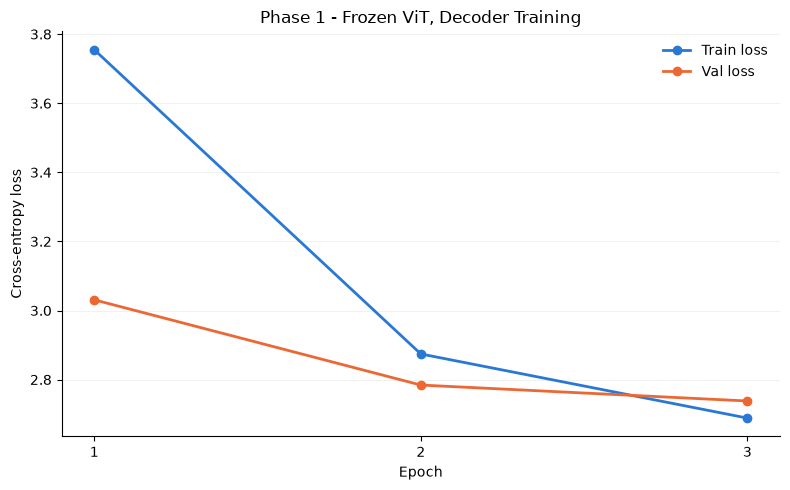

In [22]:
frozen_ckpt = torch.load(FROZEN_CKPT_PATH, map_location=device)
transfer_model.load_state_dict(frozen_ckpt["model_state"])

frozen_val_loss = validate(transfer_model, transfer_val_loader, LIMIT_VAL_BATCHES)

print(f"Best frozen checkpoint: epoch {frozen_ckpt['epoch']} | val loss {frozen_ckpt['val_loss']:.4f}")
print(f"Frozen ViT + Decoder val loss: {frozen_val_loss:.4f} | perplexity {math.exp(frozen_val_loss):.2f}")
print(f"Scratch ViT val loss (Notebook 04): {scratch_ckpt['best_val_loss']:.4f}")

def plot_curves(train_losses, val_losses, title, boundary=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs_range = range(1, len(train_losses) + 1)

    ax.plot(epochs_range, train_losses, color="#2a78d6", linewidth=2, marker="o", markersize=6, label="Train loss")
    ax.plot(epochs_range, val_losses, color="#eb6834", linewidth=2, marker="o", markersize=6, label="Val loss")

    if boundary is not None:
        ax.axvline(boundary + 0.5, color="#888888", linewidth=1, linestyle="--")
        ax.text(boundary + 0.6, ax.get_ylim()[1], "fine-tune starts", color="#555555", fontsize=9, va="top")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title(title)
    ax.set_xticks(list(epochs_range))
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)

    plt.tight_layout()
    plt.show()

plot_curves(history_frozen["train_loss"], history_frozen["val_loss"], "Phase 1 - Frozen ViT, Decoder Training")


## 14. Generate Captions

Batched greedy decoding: start every sequence at `<sos>`, feed the batch back in, take the argmax of the last position, stop when all rows hit `<eos>` or MAX_CAPTION_LEN.

Four fixed val images are reused in section 19 so all three models are shown on the same pictures.


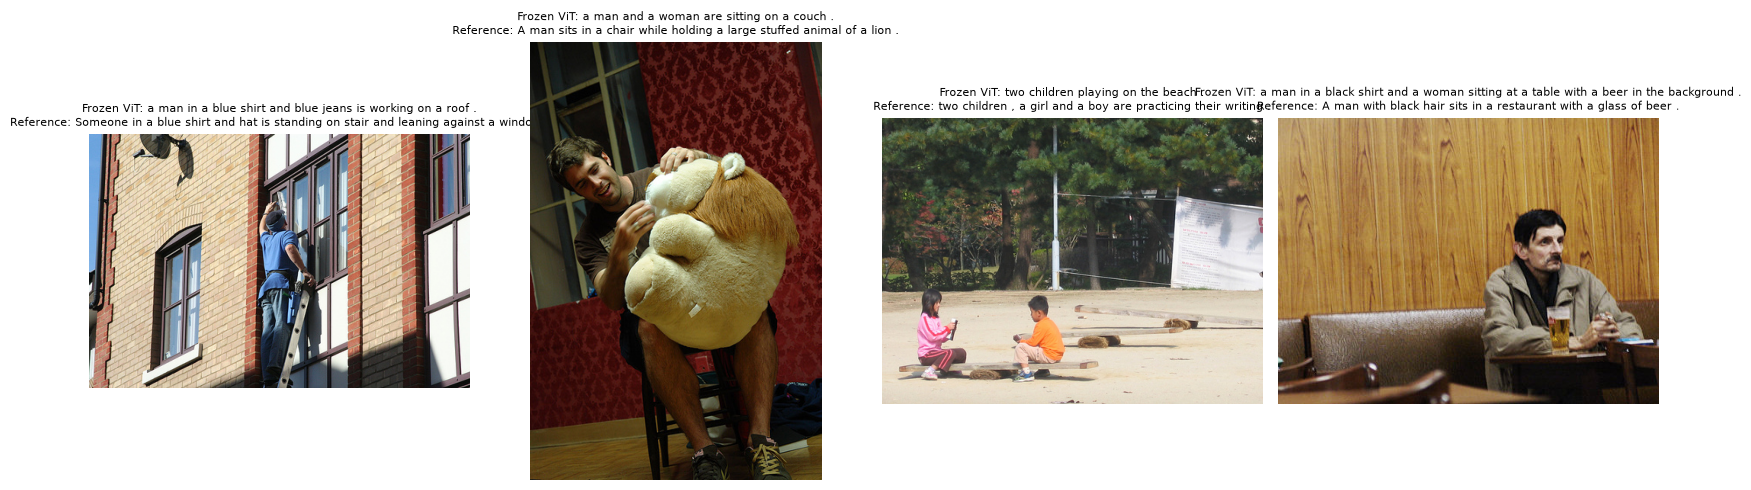

In [23]:
@torch.no_grad()
def generate_captions(model, images, max_len=MAX_CAPTION_LEN):
    model.eval()
    images = images.to(device)
    memory = model.encoder.forward_features(images)

    B = images.size(0)
    generated = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=device)
    finished = torch.zeros(B, dtype=torch.bool, device=device)

    for _ in range(max_len - 1):
        step_logits = model.decoder(generated, memory)
        next_token = step_logits[:, -1].argmax(dim=-1)
        next_token = torch.where(finished, torch.full_like(next_token, PAD_IDX), next_token)
        generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
        finished |= next_token == EOS_IDX
        if finished.all():
            break

    return [vocab.decode(row.tolist()) for row in generated]

sample_rows = val_df.drop_duplicates(subset="image").head(4).reset_index(drop=True)
sample_pil_images = [Image.open(path).convert("RGB") for path in sample_rows["image_path"]]
sample_transfer_images = torch.stack([transfer_eval_transform(img) for img in sample_pil_images])
sample_scratch_images = torch.stack([scratch_eval_transform(img) for img in sample_pil_images])

frozen_captions = generate_captions(transfer_model, sample_transfer_images)

fig, axes = plt.subplots(1, len(sample_pil_images), figsize=(16, 5))
for idx, ax in enumerate(axes):
    ax.imshow(sample_pil_images[idx])
    ax.set_title(f"Frozen ViT: {frozen_captions[idx]}\nReference: {sample_rows.loc[idx, 'caption']}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 15. Evaluate

Scratch ViT vs Frozen ViT + Decoder

Val loss / perplexity → teacher-forced, from the val split.
BLEU-1 … BLEU-4 → greedy captions for EVAL_NUM_IMAGES unique test images, scored against all reference captions of each image (corpus BLEU with brevity penalty).

Both models are evaluated on identical images and references.


In [24]:
def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1))

def corpus_bleu(hypotheses, references_list, max_n=4):
    clipped = [0] * max_n
    totals = [0] * max_n
    hyp_len_sum = 0
    ref_len_sum = 0

    for hyp, refs in zip(hypotheses, references_list):
        hyp_tokens = Vocabulary.tokenize(hyp)
        ref_tokens_list = [Vocabulary.tokenize(ref) for ref in refs]

        hyp_len_sum += len(hyp_tokens)
        ref_len_sum += min((len(r) for r in ref_tokens_list), key=lambda l: (abs(l - len(hyp_tokens)), l))

        for n in range(1, max_n + 1):
            hyp_counts = ngram_counts(hyp_tokens, n)
            max_ref_counts = Counter()
            for ref_tokens in ref_tokens_list:
                for gram, count in ngram_counts(ref_tokens, n).items():
                    max_ref_counts[gram] = max(max_ref_counts[gram], count)
            clipped[n - 1] += sum(min(count, max_ref_counts[gram]) for gram, count in hyp_counts.items())
            totals[n - 1] += max(len(hyp_tokens) - n + 1, 0)

    brevity_penalty = 1.0 if hyp_len_sum > ref_len_sum else math.exp(1 - ref_len_sum / max(hyp_len_sum, 1))

    scores = {}
    for n in range(1, max_n + 1):
        precisions = [(clipped[i] if clipped[i] > 0 else 0.1) / max(totals[i], 1) for i in range(n)]
        scores[f"BLEU-{n}"] = brevity_penalty * math.exp(sum(math.log(p) for p in precisions) / n)
    return scores

eval_df = test_df.drop_duplicates(subset="image").head(EVAL_NUM_IMAGES).reset_index(drop=True)
references_by_image = test_df.groupby("image")["caption"].apply(lambda s: [str(c) for c in s])
eval_references = [references_by_image[image] for image in eval_df["image"]]

def generate_for_paths(model, image_paths, transform):
    loader = DataLoader(ImageDataset(image_paths, transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=EFFECTIVE_NUM_WORKERS)
    hypotheses = []
    for batch in loader:
        hypotheses.extend(generate_captions(model, batch))
    return hypotheses

def evaluate_model(model, val_loader, eval_transform):
    val_loss = validate(model, val_loader, LIMIT_VAL_BATCHES)
    hypotheses = generate_for_paths(model, eval_df["image_path"], eval_transform)
    bleu = corpus_bleu(hypotheses, eval_references)
    return {"val_loss": val_loss, "perplexity": math.exp(val_loss), **bleu}

results = {}
results["Scratch ViT"] = evaluate_model(scratch_model, scratch_val_loader, scratch_eval_transform)
results["Frozen ViT + Decoder"] = evaluate_model(transfer_model, transfer_val_loader, transfer_eval_transform)

print(f"Evaluation images: {len(eval_df)} | references per image: {sum(len(r) for r in eval_references) / len(eval_references):.1f}")
display(pd.DataFrame(results).T.round(4))


Evaluation images: 500 | references per image: 5.0


,val_loss,perplexity,BLEU-1,BLEU-2,BLEU-3,BLEU-4
Scratch ViT,3.0184,20.4586,0.4904,0.2766,0.1616,0.1005
Frozen ViT + Decoder,2.7380,15.4565,0.6623,0.4671,0.3252,0.2267


## 16. Unfreeze ViT

requires_grad = True for every ViT parameter.

Trainable: ViT + projection + decoder.


In [25]:
transfer_model.encoder.unfreeze_vit()

print(f"ViT trainable: {count_trainable(transfer_model.encoder.vit):,} / {count_parameters(transfer_model.encoder.vit):,}")
print(f"Total trainable: {count_trainable(transfer_model):,} / {count_parameters(transfer_model):,}")

assert count_trainable(transfer_model) == count_parameters(transfer_model)


ViT trainable: 85,798,656 / 85,798,656
Total trainable: 93,605,851 / 93,605,851


## 17. Fine-Tune

Phase 2: continue from the best frozen checkpoint with everything trainable.

Two learning rates:
ViT → 1e-5 (pretrained weights, move gently)
Projection + decoder → 5e-5

Best checkpoint by val loss → checkpoints/best_transfer_finetuned.pt

Reduce BATCH_SIZE to 16 if the GPU runs out of memory in this phase.


In [26]:
FINETUNE_CKPT_PATH = CHECKPOINT_DIR / "best_transfer_finetuned.pt"

finetune_param_groups = [
    {"params": list(transfer_model.encoder.vit.parameters()), "lr": LR_FINETUNE_VIT},
    {"params": list(transfer_model.encoder.proj.parameters()) + list(transfer_model.decoder.parameters()), "lr": LR_FINETUNE_DECODER},
]

history_finetune, best_finetune_val_loss = run_training(
    transfer_model,
    finetune_param_groups,
    EPOCHS_FINETUNE,
    FINETUNE_CKPT_PATH,
    phase="finetune",
)


[finetune] steps/epoch 3476 | total steps 6952 | warmup 347 | trainable params 93,605,851
epoch 1/2 | step 100/3476 | loss 2.6986 | lr 2.9e-06/1.5e-05
epoch 1/2 | step 200/3476 | loss 2.7464 | lr 5.8e-06/2.9e-05
epoch 1/2 | step 300/3476 | loss 2.6822 | lr 8.7e-06/4.3e-05
epoch 1/2 | step 400/3476 | loss 2.7156 | lr 1.0e-05/5.0e-05
epoch 1/2 | step 500/3476 | loss 2.7077 | lr 1.0e-05/5.0e-05
epoch 1/2 | step 600/3476 | loss 2.6523 | lr 1.0e-05/5.0e-05
epoch 1/2 | step 700/3476 | loss 2.7095 | lr 9.9e-06/5.0e-05
epoch 1/2 | step 800/3476 | loss 2.7169 | lr 9.9e-06/4.9e-05
epoch 1/2 | step 900/3476 | loss 2.4611 | lr 9.8e-06/4.9e-05
epoch 1/2 | step 1000/3476 | loss 2.7716 | lr 9.8e-06/4.9e-05
epoch 1/2 | step 1100/3476 | loss 2.7555 | lr 9.7e-06/4.8e-05
epoch 1/2 | step 1200/3476 | loss 2.6868 | lr 9.6e-06/4.8e-05
epoch 1/2 | step 1300/3476 | loss 2.4405 | lr 9.5e-06/4.7e-05
epoch 1/2 | step 1400/3476 | loss 2.6652 | lr 9.4e-06/4.7e-05
epoch 1/2 | step 1500/3476 | loss 2.5634 | lr 9.3e-

## 18. Validate

Reload best_transfer_finetuned.pt
      ↓
Val loss
      ↓
Combined curves (phase 1 → phase 2)


Best fine-tuned checkpoint: epoch 2 | val loss 2.6742
Fine-tuned ViT + Decoder val loss: 2.6742 | perplexity 14.50
Frozen ViT + Decoder val loss:     2.7380
Scratch ViT val loss:              3.0184


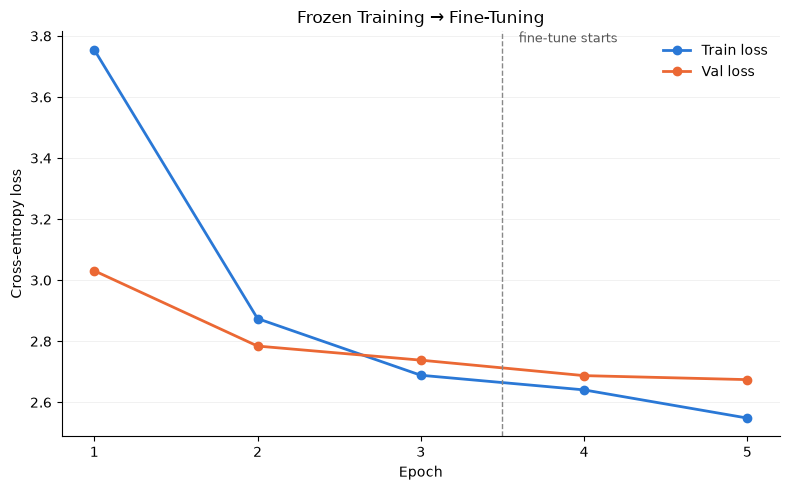

In [27]:
finetune_ckpt = torch.load(FINETUNE_CKPT_PATH, map_location=device)
transfer_model.load_state_dict(finetune_ckpt["model_state"])

finetune_val_loss = validate(transfer_model, transfer_val_loader, LIMIT_VAL_BATCHES)

print(f"Best fine-tuned checkpoint: epoch {finetune_ckpt['epoch']} | val loss {finetune_ckpt['val_loss']:.4f}")
print(f"Fine-tuned ViT + Decoder val loss: {finetune_val_loss:.4f} | perplexity {math.exp(finetune_val_loss):.2f}")
print(f"Frozen ViT + Decoder val loss:     {frozen_val_loss:.4f}")
print(f"Scratch ViT val loss:              {results['Scratch ViT']['val_loss']:.4f}")

plot_curves(
    history_frozen["train_loss"] + history_finetune["train_loss"],
    history_frozen["val_loss"] + history_finetune["val_loss"],
    "Frozen Training → Fine-Tuning",
    boundary=len(history_frozen["train_loss"]),
)


## 19. Generate Captions

Same four val images, three models:

Scratch ViT
Frozen ViT + Decoder
Fine-tuned ViT + Decoder


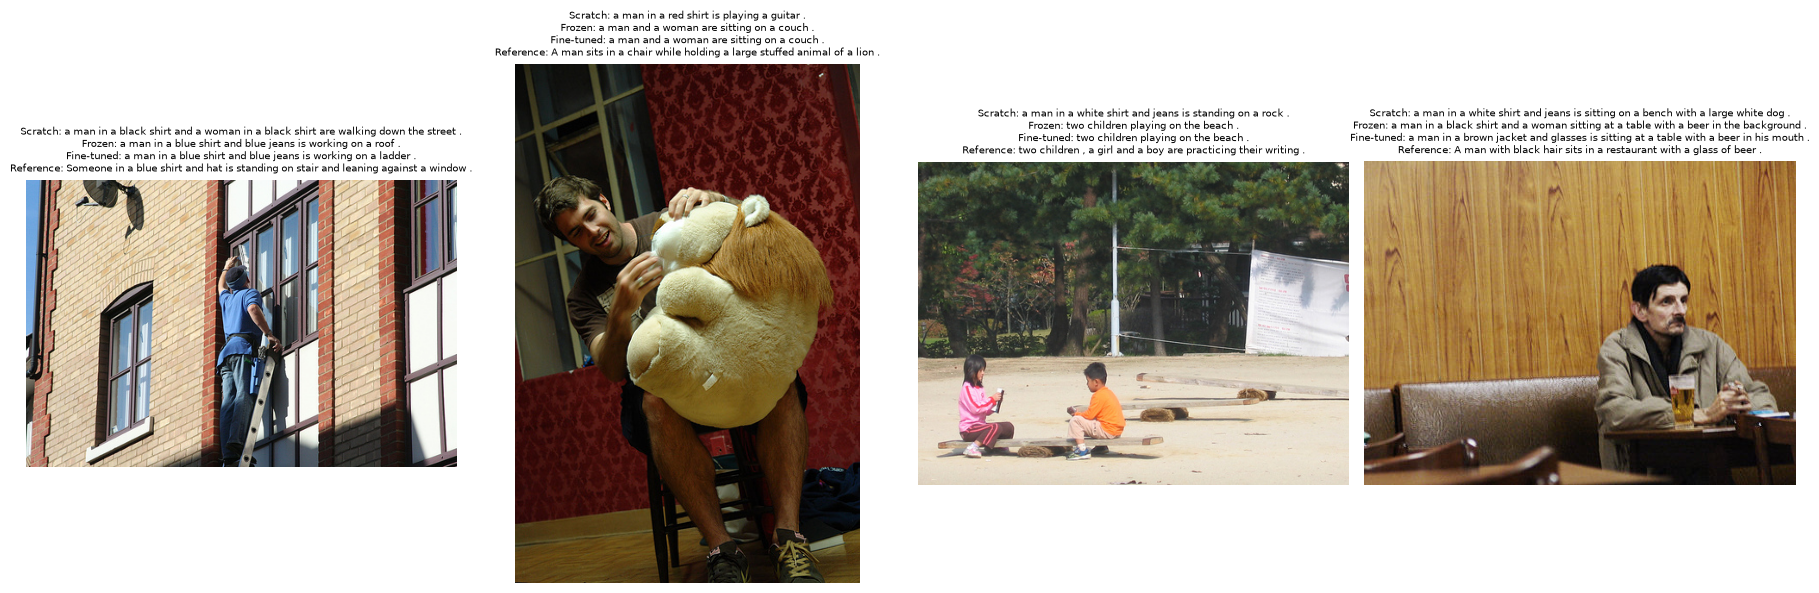

In [28]:
scratch_captions = generate_captions(scratch_model, sample_scratch_images)
finetuned_captions = generate_captions(transfer_model, sample_transfer_images)

fig, axes = plt.subplots(1, len(sample_pil_images), figsize=(18, 6))
for idx, ax in enumerate(axes):
    ax.imshow(sample_pil_images[idx])
    ax.set_title(
        f"Scratch: {scratch_captions[idx]}\n"
        f"Frozen: {frozen_captions[idx]}\n"
        f"Fine-tuned: {finetuned_captions[idx]}\n"
        f"Reference: {sample_rows.loc[idx, 'caption']}",
        fontsize=7,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 20. Evaluate

Compare all 3 models on the same metrics, images and references as section 15.


,val_loss,perplexity,BLEU-1,BLEU-2,BLEU-3,BLEU-4
Scratch ViT,3.0184,20.4586,0.4904,0.2766,0.1616,0.1005
Frozen ViT + Decoder,2.7380,15.4565,0.6623,0.4671,0.3252,0.2267
Fine-tuned ViT + Decoder,2.6742,14.5012,0.6790,0.4916,0.3528,0.2537


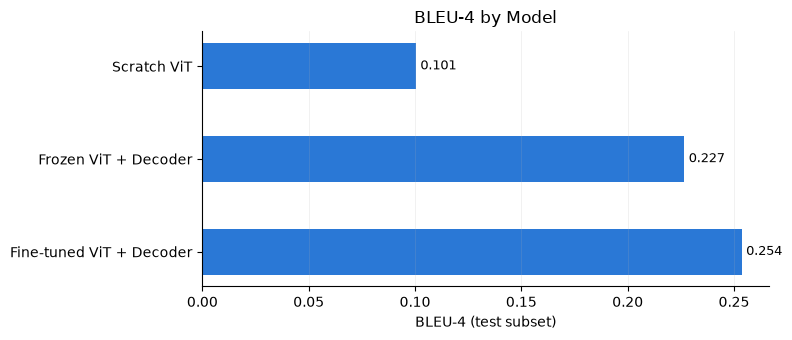

In [29]:
results["Fine-tuned ViT + Decoder"] = evaluate_model(transfer_model, transfer_val_loader, transfer_eval_transform)

results_df = pd.DataFrame(results).T.round(4)
display(results_df)

fig, ax = plt.subplots(figsize=(8, 3.5))
model_names = list(results_df.index)
bleu4 = results_df["BLEU-4"].tolist()
bars = ax.barh(model_names, bleu4, color="#2a78d6", height=0.5)
for bar, value in zip(bars, bleu4):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=9)
ax.set_xlabel("BLEU-4 (test subset)")
ax.set_title("BLEU-4 by Model")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25, linewidth=0.5)
plt.tight_layout()
plt.show()


## 21. Save Best Model

Lower val loss between the frozen and fine-tuned checkpoints wins.

Weights + vocabulary + config + all comparison metrics in one file:
src/models/vit_transfer_captioner.pt


In [30]:
candidates = {
    "frozen": (results["Frozen ViT + Decoder"]["val_loss"], FROZEN_CKPT_PATH),
    "finetune": (results["Fine-tuned ViT + Decoder"]["val_loss"], FINETUNE_CKPT_PATH),
}
best_phase = min(candidates, key=lambda k: candidates[k][0])
best_val_loss, best_ckpt_path = candidates[best_phase]

best_ckpt = torch.load(best_ckpt_path, map_location=device)
transfer_model.load_state_dict(best_ckpt["model_state"])

FINAL_MODEL_PATH = MODEL_DIR / "vit_transfer_captioner.pt"

torch.save(
    {
        "model_state": transfer_model.state_dict(),
        "vocab_itos": vocab.itos,
        "best_phase": best_phase,
        "best_val_loss": best_val_loss,
        "results": results,
        "config": {
            "pretrained_model_name": PRETRAINED_MODEL_NAME,
            "img_size": PRETRAINED_IMG_SIZE,
            "image_mean": PRETRAINED_MEAN,
            "image_std": PRETRAINED_STD,
            "embed_dim": EMBED_DIM,
            "decoder_depth": DECODER_DEPTH,
            "num_heads": NUM_HEADS,
            "mlp_ratio": MLP_RATIO,
            "dropout": DROPOUT,
            "max_caption_len": MAX_CAPTION_LEN,
            "min_word_freq": scratch_config["min_word_freq"],
        },
    },
    FINAL_MODEL_PATH,
)

print(f"Best phase: {best_phase} | val loss {best_val_loss:.4f}")
print(f"Saved: {FINAL_MODEL_PATH}")


Best phase: finetune | val loss 2.6742
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\src\models\vit_transfer_captioner.pt
